In [270]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42) #ensure reproducibility

#### Extract Data

In [271]:
#import the data
df = pd.read_csv("4H03 Data.csv")

#ignore the subject column for this study
data = df.drop(columns = ['subject'])

#check for nulls
data.isnull().any()

message    False
label      False
dtype: bool

In [272]:
#extract 1000 random emails from dataset
set = data.sample(1000, random_state=42) 
set = set.reset_index(drop = True) #reset the index

In [273]:
#summary of spam and non-spam emails
#Spam is 1 and Non-Spam is 0
set.groupby('label').describe()

message                                                               
        count unique                                                top freq
label                                                                       
0         812    812  the university of edinburgh institute for appl...    1
1         188    184  = 20 the virtual girlfriend and virtual boyfri...    2

Text(0.5, 1.0, 'Distribution of Spam vs Non-Spam')

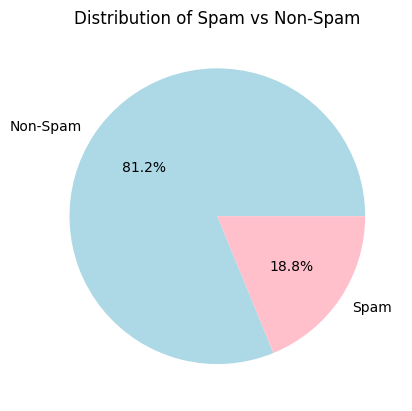

In [274]:
#visualizing data
count = set['label'].value_counts()
plt.pie(count, autopct='%1.1f%%', labels = ["Non-Spam", "Spam"], colors = ["lightblue","pink"])
plt.title(f'Distribution of Spam vs Non-Spam')

#### Preprocessing

In [275]:
#import stopwords from stopwords dataset
#https://www.kaggle.com/datasets/amirhoseinsedaghati/english-stopwords
with open('EN-Stopwords.txt') as stop:
    stopwords = [w.strip() for w in stop]

In [276]:
#import suffix table generated by Claude
suffix_table = pd.read_csv('suffix_table_sorted.csv')
suffix = suffix_table['Suffix']
replacement = suffix_table['Replacement'].fillna("")

#stemming function
def stemming(text):
    for i in range(len(suffix)):
        s = suffix[i]
        r = replacement[i]

        if text.endswith(s.strip('-')): #check if text ends with a suffix
            root = text[:len(text) - len(s.strip('-'))] + r #if yes, extract root word and add replacement
            
            if root[-1] == root[-2]: #remove duplicats character like in running
                root = root[:-1]

            if len(root) >= 3: #avoid over-stemming
                return root
    
    return text #return orginal text if already in roott format

In [277]:
import contractions #https://medium.com/@lukei_3514/dealing-with-contractions-in-nlp-d6174300876b

#preprocessing function
def preprocessing(text):
    text = text.lower() #prevent case sensitivity
    text = contractions.fix(text) #expand contractions e.g don't to do not
    text = re.sub(r'[^a-zA-Z]', ' ', text) #remove special characters
    token = text.split() #split string into individual words
    remove = [w for w in token if w not in stopwords] #remove stopwords
    processed = [stemming(w) for w in remove] #stemming

    return ' '.join(processed)